In [1]:
%run "coli starting run.ipynb"

In [2]:


score_borad = data_create(0,0,0,0)
for i in range(50):
    true_score = i*10+101
    score_borad = pd.concat([score_borad,data_create(100,my_floor(true_score,-2),true_score,0)]).reset_index(drop=True)



score_borad['int_score'] = score_borad['score']
score_borad['play_time'] = score_borad.apply(lambda x: 0 if x['type']==1 else x['play_time'],axis=1)
#score_borad['score'] = score_borad['score']-100
score_borad

,score,true score,skiped time,att count,def count,att win,def win,type,play_time,int_score
0,100.0,101,0,0,0,0,0,0,19.0,100.0
1,100.0,101,0,0,0,0,0,0,6.0,100.0
2,100.0,101,0,0,0,0,0,0,3.0,100.0
3,100.0,101,0,0,0,0,0,0,14.0,100.0
4,100.0,101,0,0,0,0,0,0,5.0,100.0
...,...,...,...,...,...,...,...,...,...,...
4995,500.0,591,0,0,0,0,0,0,7.0,500.0
4996,500.0,591,0,0,0,0,0,0,4.0,500.0
4997,500.0,591,0,0,0,0,0,0,13.0,500.0
4998,500.0,591,0,0,0,0,0,0,17.0,500.0


In [3]:
np.random.seed(5)
for i in range(20):
    score_borad = score_borad.sample(frac=1)
    print(i,end="\r", flush=True)
    for id_1 in score_borad.index:
        if score_borad.loc[id_1,'type'] == 2:
            if (i<5):
                score_borad.loc[id_1,'skiped time'] = score_borad.loc[id_1,'skiped time']+1
                continue
        if score_borad.loc[id_1,'att count'] >=score_borad.loc[id_1,'play_time']:
            continue
        pick_list = abs(score_borad['score'] - score_borad.loc[id_1,'score']).drop(id_1).sample(frac=1).sort_values().head(2)
        pick_list = score_borad.loc[pick_list.index]
        id_2 = pick_list[pick_list['true score']==pick_list['true score'].min()].index[0]#np.random.choice(pick_list.index)
        s1,s2 = coli_fight2(score_borad.loc[id_1,'score'],score_borad.loc[id_2,'score'],score_borad.loc[id_1,'true score'],score_borad.loc[id_2,'true score'])
        if s1 > score_borad.loc[id_1,'score']:
            score_borad.loc[id_1,'att win'] = score_borad.loc[id_1,'att win']+1
        else:
            score_borad.loc[id_2,'def win'] = score_borad.loc[id_2,'def win']+1
        score_borad.loc[id_1,'score'],score_borad.loc[id_2,'score'] = s1,s2
        score_borad.loc[id_1,'att count'],score_borad.loc[id_2,'def count'] = score_borad.loc[id_1,'att count']+1,score_borad.loc[id_2,'def count']+1
score_borad['scorediff'] = score_borad['score'] - score_borad['int_score']
score_borad

,score,true score,skiped time,att count,def count,att win,def win,type,play_time,int_score,scorediff
1522,370.0,251,0,17,11,11,4,0,17.0,200.0,170.0
2246,480.0,321,0,19,17,12,6,0,19.0,300.0,180.0
1446,230.0,241,0,3,12,3,3,0,3.0,200.0,30.0
3584,440.0,451,0,2,6,1,3,0,2.0,400.0,40.0
4172,540.0,511,0,6,11,4,3,0,6.0,500.0,40.0
...,...,...,...,...,...,...,...,...,...,...,...
4764,520.0,571,0,1,3,1,1,0,1.0,500.0,20.0
1328,270.0,231,0,10,13,6,4,0,10.0,200.0,70.0
1774,260.0,271,0,6,6,3,3,0,6.0,200.0,60.0
3759,590.0,471,0,17,12,8,8,0,17.0,400.0,190.0


<AxesSubplot:xlabel='score', ylabel='true score'>

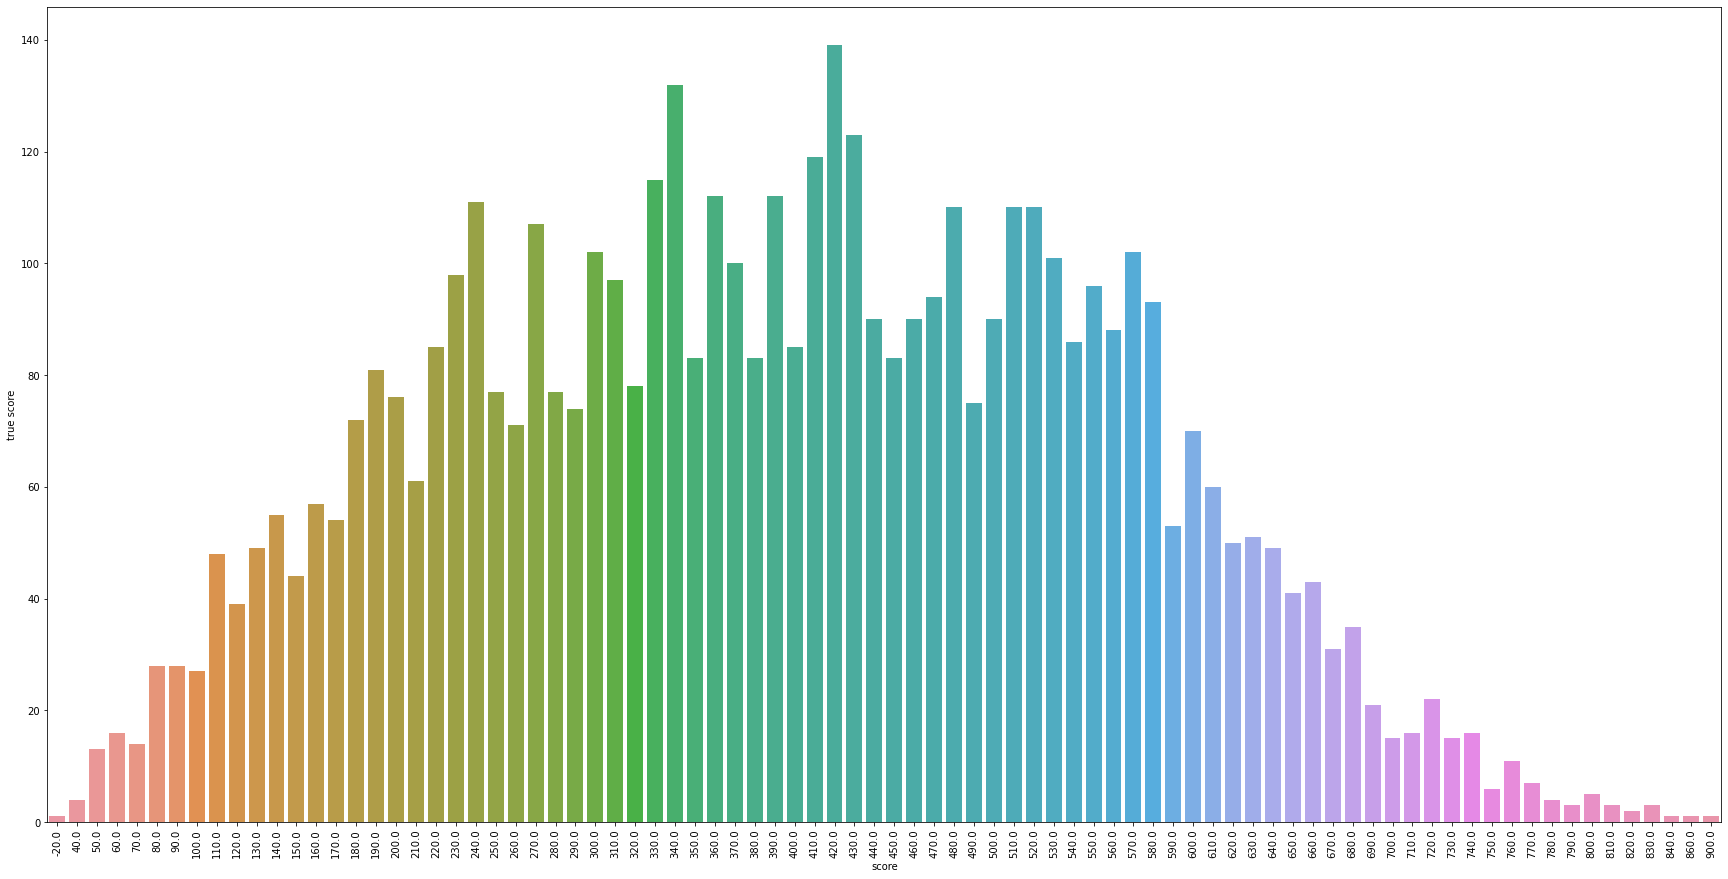

In [4]:
review_df = score_borad.groupby('score')['true score'].count()
fig, ax = plt.subplots(1,figsize=(30, 15),sharey=True)
ax.tick_params(axis='x',labelrotation=90)
sns.barplot(review_df.index,review_df)
#review_df

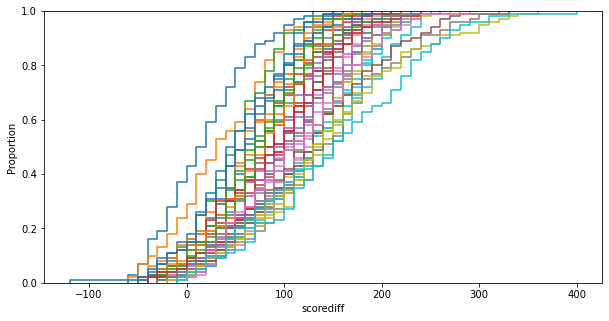

In [5]:


#review_df =score_borad.groupby('scorediff')['true score'].count()/len(score_borad)
kk = score_borad['true score'].unique()
kk.sort()
fig, ax = plt.subplots(1,figsize=(10, 5),sharey=True)
for t_score in kk:
    
    #ax.set_title(str(t_score))
    sns.ecdfplot(data = score_borad[score_borad['true score']==t_score],x="scorediff")
    #fig.show()

In [6]:
score_borad.pivot_table(index ='true score',columns='type' )#.loc[300:399]

,att count,att win,def count,def win,int_score,play_time,score,scorediff,skiped time
type,0,0,0,0,0,0,0,0,0
true score,,,,,,,,,
101,10.12,4.89,14.06,3.75,100.0,10.12,117.4,17.4,0
111,9.74,5.14,12.25,3.39,100.0,9.74,136.0,36.0,0
121,9.42,4.86,11.55,3.74,100.0,9.42,148.3,48.3,0
131,9.87,5.78,11.32,3.73,100.0,9.87,173.4,73.4,0
141,9.78,5.82,9.94,3.55,100.0,9.78,183.9,83.9,0
151,8.90,5.52,9.31,3.44,100.0,8.90,186.7,86.7,0
161,9.22,5.91,9.59,3.76,100.0,9.22,202.0,102.0,0
171,10.10,6.70,8.75,3.58,100.0,10.10,219.9,119.9,0


In [7]:
score_borad.pivot_table(index ='true score',columns='type' ).loc[300:399]

,att count,att win,def count,def win,int_score,play_time,score,scorediff,skiped time
type,0,0,0,0,0,0,0,0,0
true score,,,,,,,,,
301,10.19,6.05,13.38,3.84,300.0,10.19,361.0,61.0,0
311,8.99,5.16,11.72,3.83,300.0,8.99,362.6,62.6,0
321,9.93,5.98,11.47,3.55,300.0,9.93,371.9,71.9,0
331,9.42,5.73,11.17,4.11,300.0,9.42,389.3,89.3,0
341,9.84,6.10,9.71,3.59,300.0,9.84,395.2,95.2,0
351,9.88,6.26,8.78,3.47,300.0,9.88,405.3,105.3,0
361,9.74,6.34,8.72,3.61,300.0,9.74,413.9,113.9,0
371,9.07,6.16,8.14,3.32,300.0,9.07,412.3,112.3,0
